In [1]:
import pandas as pd 

AIME_24 = pd.read_csv("results_AIME2024.csv")
AIME_25 = pd.read_csv("results_AIME2025.csv")
df = pd.concat([AIME_24, AIME_25])


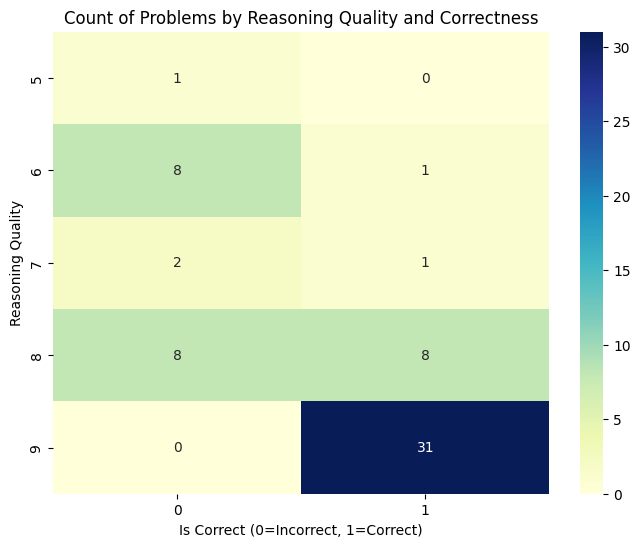

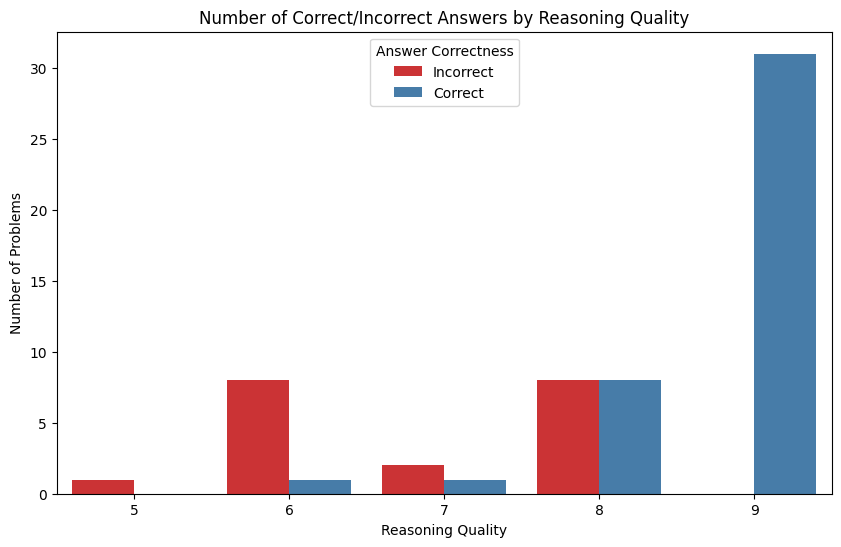

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

pivot = df.groupby(['is_correct', 'reasoning_quality']).agg({'problem_id': 'count'}).reset_index()
pivot = pivot.pivot(index='reasoning_quality', columns='is_correct', values='problem_id').fillna(0)

plt.figure(figsize=(8, 6))
sns.heatmap(pivot, annot=True, fmt=".0f", cmap="YlGnBu")
plt.title("Count of Problems by Reasoning Quality and Correctness")
plt.xlabel("Is Correct (0=Incorrect, 1=Correct)")
plt.ylabel("Reasoning Quality")
plt.show()

# Prepare the data
bar_data = df.groupby(['reasoning_quality', 'is_correct']).agg({'problem_id': 'count'}).reset_index()
bar_data['is_correct'] = bar_data['is_correct'].map({0: 'Incorrect', 1: 'Correct'})

plt.figure(figsize=(10, 6))
sns.barplot(
    x='reasoning_quality',
    y='problem_id',
    hue='is_correct',
    data=bar_data,
    palette='Set1'
)
plt.title("Number of Correct/Incorrect Answers by Reasoning Quality")
plt.xlabel("Reasoning Quality")
plt.ylabel("Number of Problems")
plt.legend(title="Answer Correctness")
plt.show()